# Pipeline Passos Mágicos — ETL Completo Corrigido

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, warnings, joblib
from datetime import datetime

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

try:
    from xgboost import XGBClassifier
    XGB = True
except ImportError:
    XGB = False
    print("XGBoost indisponível — usando GradientBoosting")

sns.set_theme(style="whitegrid")
warnings.simplefilter("ignore")
pd.set_option("display.max_columns", None)
print("Imports OK")

Imports OK


## 1. Carregamento

In [2]:
file_path = "../data/BASE DE DADOS PEDE 2024 - DATATHON.xlsx"
xls = pd.ExcelFile(file_path)
sheets_dict = pd.read_excel(xls, sheet_name=None)
print("Abas:", list(sheets_dict.keys()))
for s, d in sheets_dict.items():
    print(f"  {s}: {d.shape}")

Abas: ['PEDE2022', 'PEDE2023', 'PEDE2024']
  PEDE2022: (860, 42)
  PEDE2023: (1014, 48)
  PEDE2024: (1156, 50)


## 2. Funções de Limpeza

In [3]:
# ── Fase ──────────────────────────────────────────────────────────────────────
def extrair_fase_ideal(val):
    if pd.isna(val): return np.nan
    s = str(val).strip()
    if "ALFA" in s.upper(): return "ALFA"
    m = re.match(r"Fase\s*(\d+)", s, re.IGNORECASE)
    return f"Fase {m.group(1)}" if m else np.nan

def normaliza_fase(val):
    if pd.isna(val): return np.nan
    s = str(val).strip()
    if s in ("", "0", "0.0", "nan"): return np.nan
    su = s.upper()
    if "ALFA" in su: return "ALFA"
    num = re.sub(r"^FASE\s*", "", su)
    num = re.sub(r"[A-Z]+$", "", num).strip()
    num = re.sub(r"\.0$", "", num)
    try: return f"Fase {int(float(num))}"
    except: return np.nan

# ── Gênero ────────────────────────────────────────────────────────────────────
def normaliza_genero(val):
    if pd.isna(val): return np.nan
    mapa = {"Menina":"Feminino","Menino":"Masculino","F":"Feminino","M":"Masculino",
            "feminino":"Feminino","masculino":"Masculino","FEMININO":"Feminino","MASCULINO":"Masculino"}
    return mapa.get(str(val).strip(), str(val).strip())

# ── Pedra ─────────────────────────────────────────────────────────────────────
_MAP_PEDRA = {
    "quartzo":"Quartzo","quarzo":"Quartzo","quarzto":"Quartzo",
    "agata":"Ágata","ágata":"Ágata",
    "ametista":"Ametista",
    "topázio":"Topázio","topazio":"Topázio","topázio":"Topázio",
}

def normaliza_pedra(val):
    if pd.isna(val): return np.nan
    s = str(val).strip()
    if s in ("0","0.0",""): return np.nan
    return _MAP_PEDRA.get(s.lower(), np.nan)

def pedra_por_inde(inde):
    if pd.isna(inde): return np.nan
    v = float(inde)
    if v < 2.405: return np.nan
    if v < 5.506: return "Quartzo"
    if v < 6.868: return "Ágata"
    if v < 8.230: return "Ametista"
    if v <= 9.294: return "Topázio"
    return np.nan

def limpa_pedra_por_ano(df_aba, ano):
    ano4 = str(ano)
    ano2 = str(ano)[-2:]
    # CRÍTICO: 4 dígitos PRIMEIRO — 'Pedra 23' pode ser coluna histórica vazia!
    candidatos = [f"Pedra {ano4}", f"PEDRA {ano4}", "Pedra", "PEDRA",
                  f"Pedra {ano2}", f"PEDRA {ano2}"]
    col = None
    for c in candidatos:
        if c in df_aba.columns and df_aba[c].notna().sum() > 0:
            col = c; break
    if col is None:
        print(f"  AVISO: sem coluna Pedra válida para {ano}")
        return pd.Series([np.nan]*len(df_aba), name="Pedra")
    print(f"  Pedra {ano} <- '{col}' ({df_aba[col].notna().sum()} válidos)")
    return df_aba[col].apply(normaliza_pedra).rename("Pedra")

# ── Texto ─────────────────────────────────────────────────────────────────────
def limpa_texto(val):
    if pd.isna(val): return np.nan
    s = str(val).strip()
    return np.nan if s in ("0","0.0","") else s

# ── Data de Nascimento ────────────────────────────────────────────────────────
def normaliza_nasc(val):
    if pd.isna(val): return (np.nan, np.nan)
    if isinstance(val, (pd.Timestamp, datetime)):
        return (int(val.year), val.strftime("%d/%m/%Y"))
    s = str(val).strip()
    if re.fullmatch(r"1\d{3}|2\d{3}", s):
        a = int(s)
        return (a, np.nan) if 1985 <= a <= 2022 else (np.nan, np.nan)
    for fmt in ("%m/%d/%Y", "%d/%m/%Y"):
        try:
            dt = pd.to_datetime(s, format=fmt)
            return (int(dt.year), dt.strftime("%d/%m/%Y"))
        except: pass
    return (np.nan, np.nan)

# ── Idade ─────────────────────────────────────────────────────────────────────
def normaliza_idade(val):
    if pd.isna(val): return np.nan
    if isinstance(val, (pd.Timestamp, datetime)):
        return int(val.day)   # Excel serial: day = idade real
    try:
        i = int(float(str(val)))
        return i if 5 <= i <= 35 else np.nan
    except: return np.nan

print("Funções definidas!")

Funções definidas!


## 3. Processamento por Aba

In [4]:
dfs = []

for sheet, df_aba in sheets_dict.items():
    m = re.search(r"20\d{2}", sheet)
    if not m: continue
    ano = int(m.group(0))
    if ano < 2022: continue

    print(f"\n--- {sheet} (ano {ano}) ---")
    df_t = df_aba.copy()
    df_t["ANO_PEDE"] = ano

    # Pedra: extrair ANTES de renomear colunas
    serie_pedra = limpa_pedra_por_ano(df_t, ano)
    cols_pedra = [c for c in df_t.columns if re.search(r"[Pp]edra|[Pp]EDRA", str(c))]
    df_t = df_t.drop(columns=cols_pedra, errors="ignore")

    # Fase por ano
    if ano == 2022 and "Fase" in df_t.columns:
        df_t["Fase"] = df_t["Fase"].apply(
            lambda x: f"Fase {int(x)}" if pd.notna(x) and str(x).strip() not in ("0","") else np.nan)
        print("  Fase 2022:", df_t["Fase"].value_counts(dropna=False).head(4).to_dict())

    elif ano == 2023 and "Fase" in df_t.columns:
        df_t["Fase"] = df_t["Fase"].apply(normaliza_fase)
        print("  Fase 2023:", df_t["Fase"].value_counts(dropna=False).head(4).to_dict())

    elif ano == 2024:
        col_fi = next((c for c in df_t.columns if "ideal" in str(c).lower()), None)
        if col_fi:
            df_t["Fase"] = df_t[col_fi].apply(extrair_fase_ideal)
            print(f"  Fase 2024 <- '{col_fi}':", df_t["Fase"].value_counts(dropna=False).head(4).to_dict())
        elif "Fase" in df_t.columns:
            df_t["Fase"] = df_t["Fase"].apply(normaliza_fase)

    # Data de Nascimento e Idade
    col_nasc = next((c for c in df_t.columns if any(x in str(c).lower()
                     for x in ["nasc","birth","data de nasc","ano nasc"])), None)
    col_idade = next((c for c in df_t.columns if "idade" in str(c).lower()), None)

    if col_nasc:
        res = df_t[col_nasc].apply(normaliza_nasc)
        df_t["ANO_NASC"] = res.apply(lambda x: x[0] if isinstance(x, tuple) else x)
        df_t["DATA_NASC_BR"] = res.apply(lambda x: x[1] if isinstance(x, tuple) else np.nan)
        print("  ANO_NASC:", df_t["ANO_NASC"].dropna().head(3).tolist())
        print("  DATA_NASC_BR:", df_t["DATA_NASC_BR"].dropna().head(3).tolist())

    if col_idade:
        df_t["IDADE"] = df_t[col_idade].apply(normaliza_idade)
        if "ANO_NASC" in df_t.columns:
            mask = df_t["IDADE"].isna() & df_t["ANO_NASC"].notna()
            df_t.loc[mask, "IDADE"] = ano - df_t.loc[mask, "ANO_NASC"]
        df_t["IDADE"] = pd.to_numeric(df_t["IDADE"], errors="coerce").astype("Int64")
        print("  IDADE:", df_t["IDADE"].dropna().head(3).tolist())

    # Normalizar nomes de colunas
    def unif(c):
        if c == "ANO_PEDE": return c
        n = re.sub(r"[\s_]*20\d{2}$", "", str(c))
        n = re.sub(r"[\s_]*\d{2}$", "", n)
        return n.strip()

    df_t.columns = [unif(c) for c in df_t.columns]
    df_t = df_t.loc[:, ~df_t.columns.duplicated()]
    df_t["Pedra"] = serie_pedra.values
    dfs.append(df_t)

df = pd.concat(dfs, ignore_index=True)
print(f"\nDataset unificado: {df.shape}")


--- PEDE2022 (ano 2022) ---
  Pedra 2022 <- 'Pedra 22' (860 válidos)
  Fase 2022: {'Fase 1': 192, nan: 190, 'Fase 2': 155, 'Fase 3': 148}
  ANO_NASC: [2003, 2005, 2005]
  DATA_NASC_BR: []
  IDADE: [19, 17, 17]

--- PEDE2023 (ano 2023) ---
  Pedra 2023 <- 'Pedra 2023' (931 válidos)
  Fase 2023: {'ALFA': 231, 'Fase 2': 200, 'Fase 1': 173, 'Fase 3': 132}
  ANO_NASC: [2015, 2014, 2016]
  DATA_NASC_BR: ['17/06/2015', '31/05/2014', '25/02/2016']
  IDADE: [8, 9, 7]

--- PEDE2024 (ano 2024) ---
  Pedra 2024 <- 'Pedra 2024' (1092 válidos)
  Fase 2024 <- 'Fase Ideal': {'Fase 2': 281, 'Fase 3': 233, 'Fase 1': 182, 'Fase 8': 102}
  ANO_NASC: [2016, 2016, 2016]
  DATA_NASC_BR: ['28/07/2016', '16/10/2016', '16/08/2016']
  IDADE: [8, 8, 8]

Dataset unificado: (3030, 58)


## 4. Limpeza Global

In [5]:
if "Gênero" in df.columns:
    df["Gênero"] = df["Gênero"].apply(normaliza_genero)
    print("Gênero:", df["Gênero"].value_counts(dropna=False).to_dict())

for col in ["Destaque IEG","Destaque IDA","Destaque IPV",
            "Rec Av1","Rec Av2","Rec Av3","Rec Av4","Rec Psicologia","Nome"]:
    if col in df.columns:
        df[col] = df[col].apply(limpa_texto)

for col in ["RA","Turma","Ano ingresso"]:
    if col in df.columns:
        df[col] = df[col].apply(lambda x: re.sub(r"\.0$","",str(x)) if pd.notna(x) else np.nan)

for col in ["IAN","IDA","IEG","IAA","IPS","IPP","IPV","INDE"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Recalcular Pedra via INDE para registros sem classificação
if "Pedra" in df.columns and "INDE" in df.columns:
    sem_pedra = df["Pedra"].isna() & df["INDE"].notna()
    df.loc[sem_pedra, "Pedra"] = df.loc[sem_pedra, "INDE"].apply(pedra_por_inde)
    print(f"Pedra recalculada via INDE: {sem_pedra.sum()} registros")

print("\n=== FASE por ANO ===")
print(pd.crosstab(df["ANO_PEDE"], df["Fase"], dropna=False))
print("\n=== PEDRA ===")
print(df["Pedra"].value_counts(dropna=False))
print("\n=== IDADE ===")
if "IDADE" in df.columns: print(df["IDADE"].describe())
print("\n=== DATA_NASC_BR (amostra) ===")
if "DATA_NASC_BR" in df.columns: print(df["DATA_NASC_BR"].dropna().head(8).tolist())

Gênero: {'Feminino': 1626, 'Masculino': 1404}
Pedra recalculada via INDE: 0 registros

=== FASE por ANO ===
Fase      ALFA  Fase 1  Fase 2  Fase 3  Fase 4  Fase 5  Fase 6  Fase 7  Fase 8
ANO_PEDE                                                                      
2022         0     192     155     148      76      60      18      21       0
2023       231     173     200     132      94      65      33      23      63
2024        49     182     281     233      90      96      70      53     102

=== PEDRA ===
Pedra
Ametista    1120
Ágata        721
Topázio      688
Quartzo      316
NaN          185
Name: count, dtype: int64

=== IDADE ===
count       3030.0
mean     12.527063
std       3.299273
min            7.0
25%           10.0
50%           12.0
75%           15.0
max           27.0
Name: IDADE, dtype: Float64

=== DATA_NASC_BR (amostra) ===
['17/06/2015', '31/05/2014', '25/02/2016', '03/12/2015', '13/11/2014', '02/10/2016', '29/06/2015', '11/08/2015']


## 5. EDA

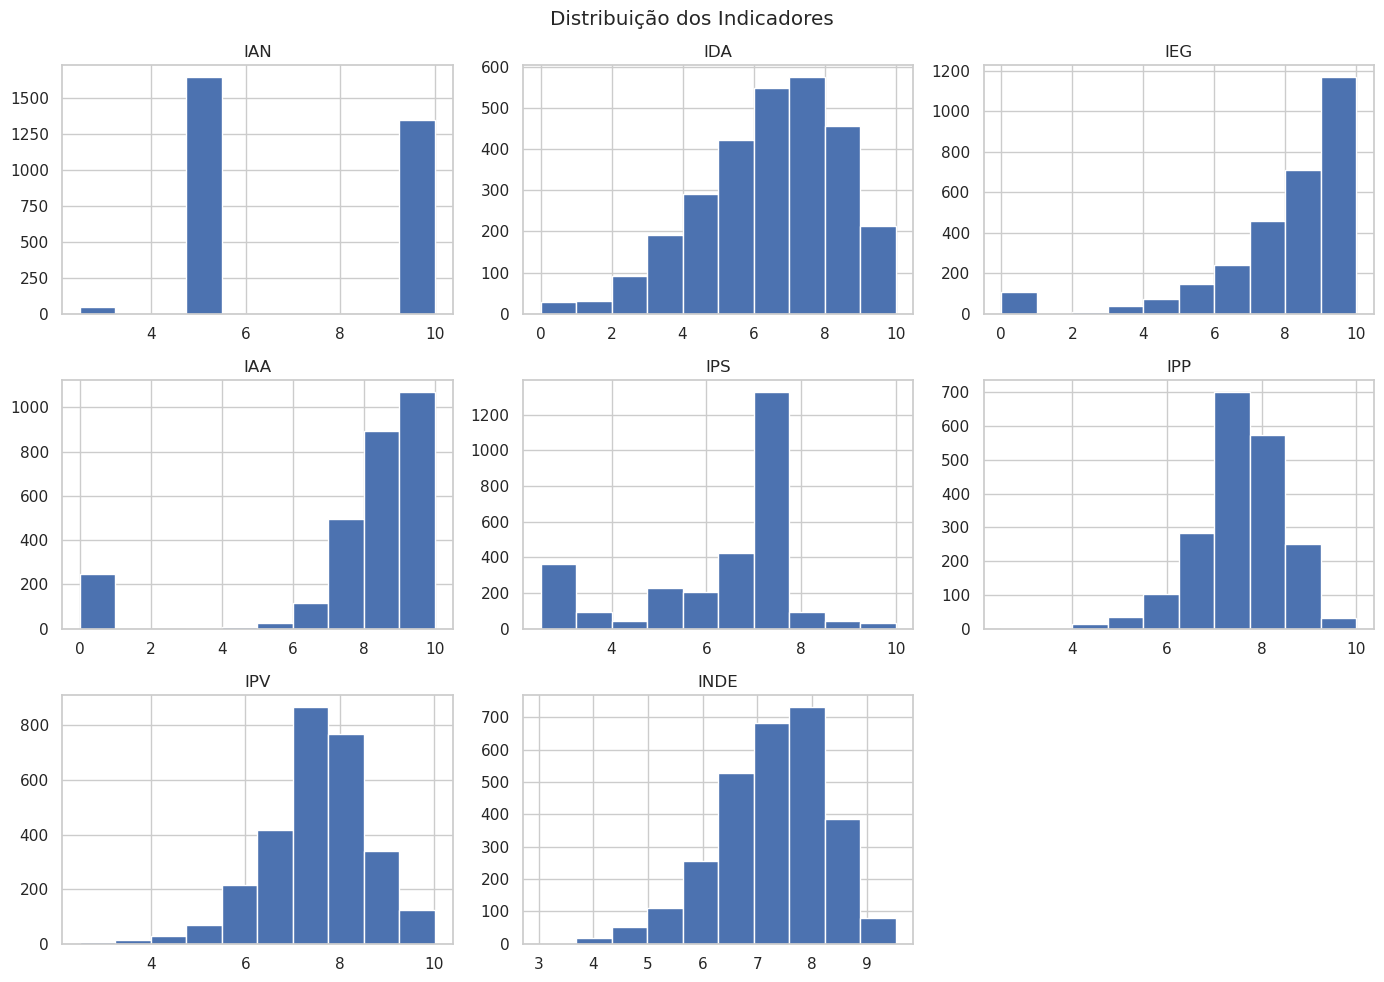

In [6]:
indicadores = ["IAN","IDA","IEG","IAA","IPS","IPP","IPV","INDE"]
ind = [c for c in indicadores if c in df.columns]
df[ind].hist(figsize=(14,10))
plt.suptitle("Distribuição dos Indicadores")
plt.tight_layout(); plt.show()

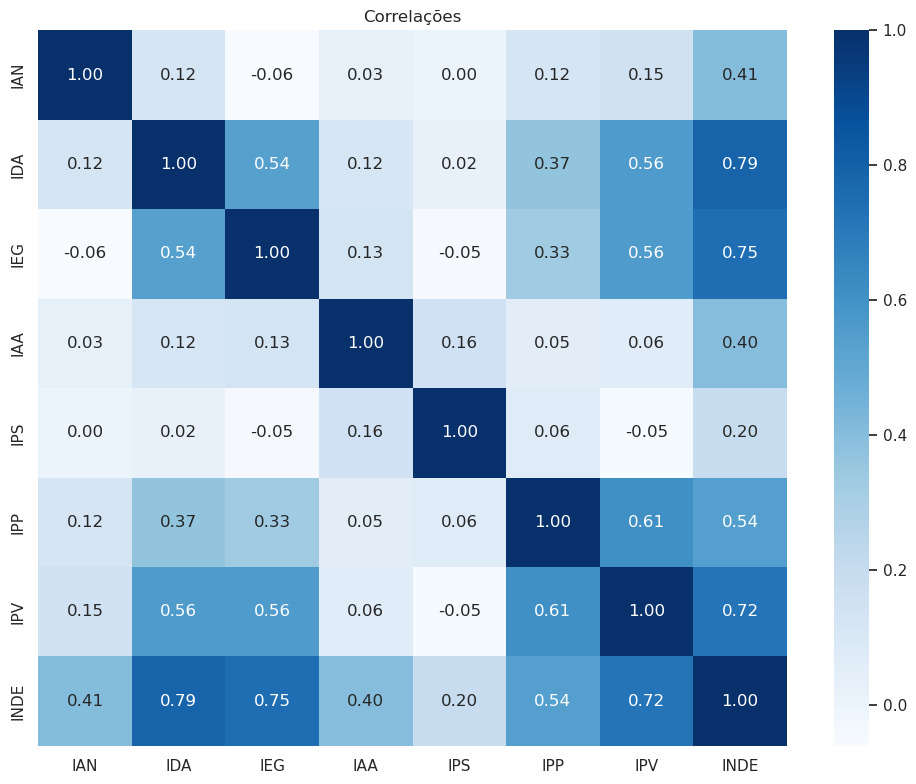

In [7]:
fig, ax = plt.subplots(figsize=(10,8))
sns.heatmap(df[ind].corr(), annot=True, fmt=".2f", cmap="Blues", ax=ax)
ax.set_title("Correlações")
plt.tight_layout(); plt.show()

## 6. Feature Engineering

In [8]:
df["ENGAJAMENTO_ACADEMICO"] = df["IEG"] * df["IDA"]
df["SUPORTE_PSICO"] = (df["IPS"] + df["IPP"]) / 2
df["SCORE_GERAL"] = (df["IDA"] + df["IEG"] + df["IAA"] + df["IPS"] + df["IPP"]) / 5

df_s = df.sort_values(["RA","ANO_PEDE"]).copy()
df["EVOLUCAO_IDA"] = df_s.groupby("RA")["IDA"].diff().fillna(0)
df["EVOLUCAO_IEG"] = df_s.groupby("RA")["IEG"].diff().fillna(0)

df["RISCO"] = (df["INDE"] < 6.0).astype(int)
print("RISCO=1:", df["RISCO"].sum(), f"({df['RISCO'].mean():.1%})")

RISCO=1: 316 (10.4%)


## 7. Exportar CSV

In [9]:
out = "../data/dados_passos_magicos_limpos.csv"
df.to_csv(out, index=False, encoding="utf-8")
print(f"CSV salvo: {out} | Shape: {df.shape}")

print("\n=== VALIDAÇÃO FINAL ===")
print("Pedra='0':", (df["Pedra"].astype(str)=="0").sum())
print("Pedra nula:", df["Pedra"].isna().sum())
print("Pedra válida:", df["Pedra"].notna().sum())
print("\nFase por ano:")
print(pd.crosstab(df["ANO_PEDE"], df["Fase"], margins=True))
if "IDADE" in df.columns:
    print(f"Idade: min={df['IDADE'].min()}, max={df['IDADE'].max()}, nulos={df['IDADE'].isna().sum()}")
if "DATA_NASC_BR" in df.columns:
    print("DATA_NASC_BR preenchidas:", df["DATA_NASC_BR"].notna().sum())

CSV salvo: ../data/dados_passos_magicos_limpos.csv | Shape: (3030, 64)

=== VALIDAÇÃO FINAL ===
Pedra='0': 0
Pedra nula: 185
Pedra válida: 2845

Fase por ano:
Fase      ALFA  Fase 1  Fase 2  Fase 3  Fase 4  Fase 5  Fase 6  Fase 7  \
ANO_PEDE                                                                 
2022         0     192     155     148      76      60      18      21   
2023       231     173     200     132      94      65      33      23   
2024        49     182     281     233      90      96      70      53   
All        280     547     636     513     260     221     121      97   

Fase      Fase 8   All  
ANO_PEDE                
2022           0   670  
2023          63  1014  
2024         102  1156  
All          165  2840  
Idade: min=7, max=27, nulos=0
DATA_NASC_BR preenchidas: 2170


## 8. Machine Learning

In [10]:
FEATURES = ["IDA","IEG","IAA","IPS","IPP","IPV","IAN",
            "ENGAJAMENTO_ACADEMICO","SUPORTE_PSICO","SCORE_GERAL",
            "EVOLUCAO_IDA","EVOLUCAO_IEG"]
TARGET = "RISCO"

df_ml = df[df["INDE"].notna()].copy()
for f in FEATURES:
    if f in df_ml.columns:
        df_ml[f] = df_ml[f].fillna(df_ml[f].median())

X = df_ml[FEATURES]
y = df_ml[TARGET]
print(f"ML Dataset: {X.shape} | RISCO=1: {y.mean():.1%}")

ML Dataset: (2845, 12) | RISCO=1: 11.1%


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

if XGB:
    n_neg, n_pos = (y_train==0).sum(), (y_train==1).sum()
    modelo = XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.05,
                           subsample=0.9, colsample_bytree=0.9,
                           scale_pos_weight=n_neg/n_pos if n_pos>0 else 1,
                           random_state=42, eval_metric="logloss",
                           use_label_encoder=False)
else:
    modelo = GradientBoostingClassifier(n_estimators=300, max_depth=6,
                                        learning_rate=0.05, random_state=42)
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)
y_prob = modelo.predict_proba(X_test)[:,1]
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
print(f"Acurácia: {acc:.4f} ({acc*100:.2f}%)")
print(f"AUC-ROC:  {auc:.4f}")
print(classification_report(y_test, y_pred, target_names=["Sem Risco","Em Risco"]))

Acurácia: 0.9859 (98.59%)
AUC-ROC:  0.9987
              precision    recall  f1-score   support

   Sem Risco       1.00      0.99      0.99       506
    Em Risco       0.90      0.98      0.94        63

    accuracy                           0.99       569
   macro avg       0.95      0.99      0.97       569
weighted avg       0.99      0.99      0.99       569



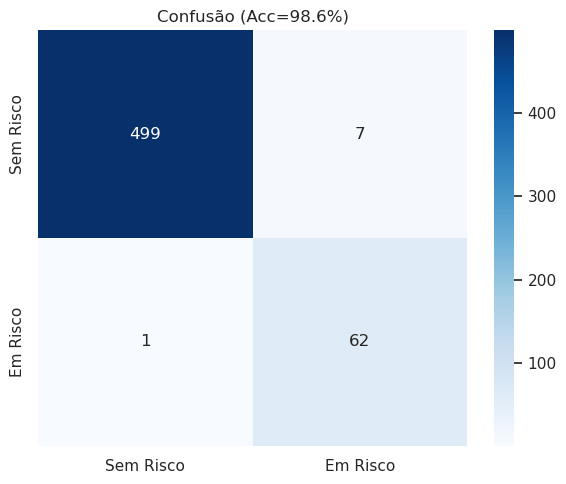

In [12]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Sem Risco","Em Risco"],
            yticklabels=["Sem Risco","Em Risco"])
ax.set_title(f"Confusão (Acc={acc*100:.1f}%)")
plt.tight_layout(); plt.show()

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(modelo, X, y, cv=cv, scoring="accuracy")
print(f"CV 5-fold: {scores.mean():.4f} ± {scores.std():.4f}")
print([f"{s:.3f}" for s in scores])

CV 5-fold: 0.9828 ± 0.0050
['0.979', '0.991', '0.986', '0.979', '0.979']


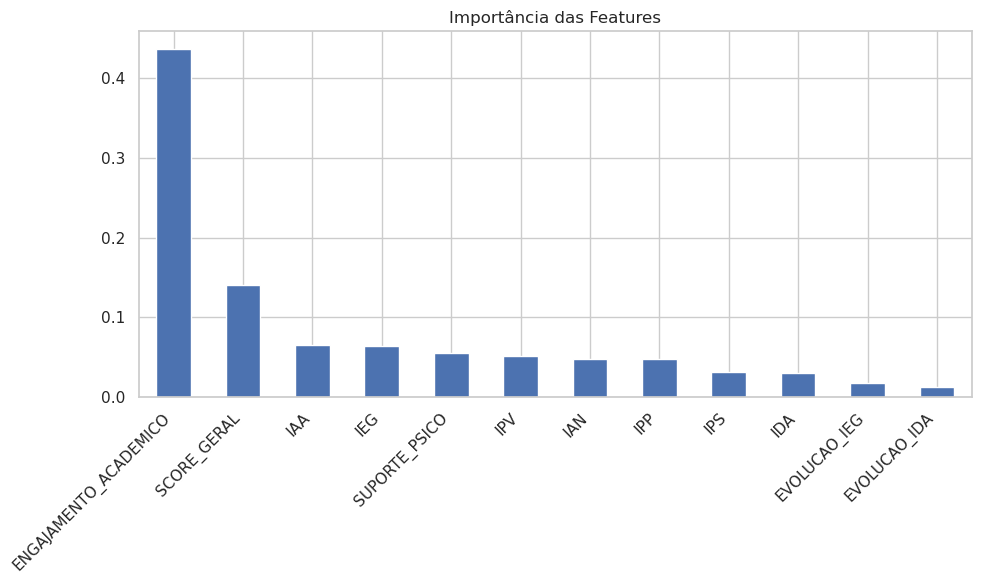

In [14]:
imps = pd.Series(modelo.feature_importances_, index=FEATURES).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10,6))
imps.plot(kind="bar", ax=ax)
ax.set_title("Importância das Features")
plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()

## 9. Salvar Modelo

In [15]:
mp = "../data/modelo_risco_passos_magicos.pkl"
joblib.dump(modelo, mp)
print(f"Modelo: {mp}")
print(f"Features: {FEATURES}")
print(f"Acurácia: {acc*100:.2f}% | AUC: {auc*100:.2f}%")

Modelo: ../data/modelo_risco_passos_magicos.pkl
Features: ['IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'IAN', 'ENGAJAMENTO_ACADEMICO', 'SUPORTE_PSICO', 'SCORE_GERAL', 'EVOLUCAO_IDA', 'EVOLUCAO_IEG']
Acurácia: 98.59% | AUC: 99.87%
